In [246]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [247]:
def f(x):
  return 3*x**2 - 4*x + 5

In [248]:
f(3.0)

20.0

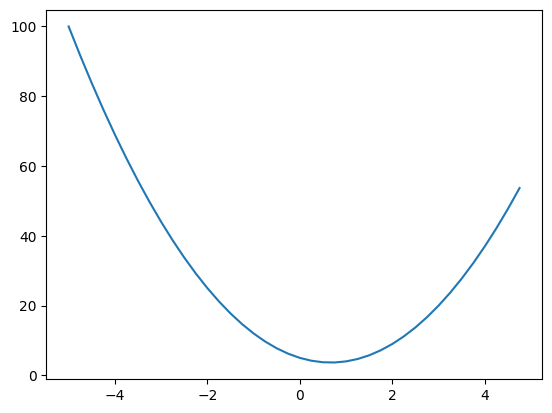

In [249]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [250]:
h = 0.000001
x = 2/3
(f(x + h) - f(x))/h

2.999378523327323e-06

In [251]:
#lets get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [252]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 -d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [253]:
class Value:

  def __init__(self, data, _children=(), _op='', label =''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other  = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    return out

  def __radd__(self, other):
        # This handles: number + Value (e.g., 0 + Value)
        return self.__add__(other)

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')


    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now."
    out = Value(self.data**other, (self, ), f'**{other}')

    def _backward():
      self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out

  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other):  # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)


  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad = out.data * out.grad
    out._backward = _backward
    return out

  def backward(self):

    # Topological graph.
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()



# (a.__mul__(b)).__add__(c) #it work like this

In [254]:
a = Value(2.0)
b = Value(4.0)
a - b


Value(data=-2.0)

In [255]:
# d._prev

In [256]:
# d._op

In [257]:
from graphviz import Digraph

def trace(root):
  #builds a set of all nodes and edges in a graph.
  nodes, edges = set(), set()
  def build(v) :
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR = left to right
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it.
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      #if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label =n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)
  for n1, n2 in edges:
    #connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
  return dot

In [258]:
# c.grad = -2
# e.grad = -2

L = d*f

dL/dd=? ->f

(f(x+h)-f(x))/h

((d+h)*f - d*f)/h

(d*f + h*f - d*f)/h

(h*f)/h

f

In [259]:
# f.grad = 4.0
# d.grad = -2

dd / dc = 1.0

dd / de = 1.0

d = c + e

Want:

dL / dc = (dL / dd) * (dd / dc)

Know:

dL / dd

dd / dc

In [260]:
# a.grad = -2.0 * -3.0
# b.grad = -2.0 * 2.0

dL / de = -2

e = a * b

de  / da? b

dL / da = (dL / de) * (de / da)



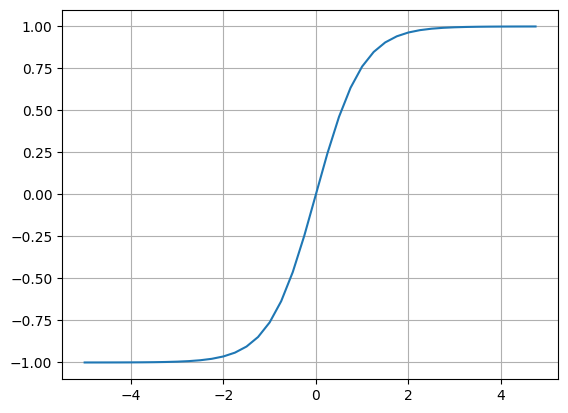

In [261]:
plt.plot(np.arange(-5,5,0.25), np.tanh(np.arange(-5,5,0.25))); plt.grid();


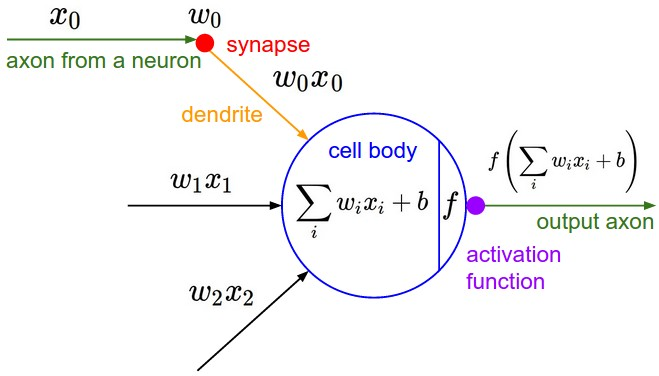

In [262]:
# two dimensional neuron.
# therefore two inputs will be present x1 and x2.

x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
# weights are the synaptic strength for each input.
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# Bias of neuron (b)
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 +x2w2; x1w1x2w2.label ='x1w1x2w2'
#n is now cell body raw activation without the activation function now.
n = x1w1x2w2 + b; n.label='n'

o = n.tanh(); o.label='o'
o.backward()

Now we will do backpropogation to fill up the grades.

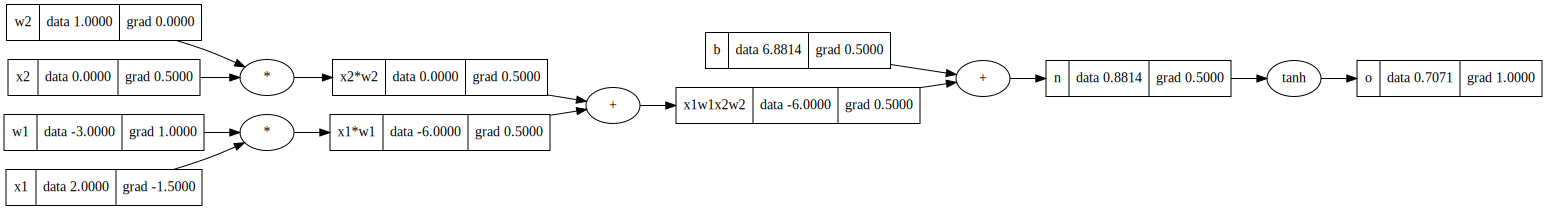

In [263]:
draw_dot(o)

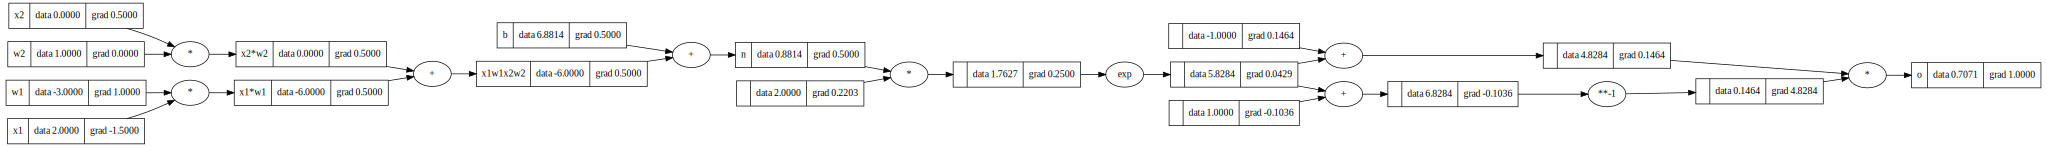

In [264]:

x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
# weights are the synaptic strength for each input.
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# Bias of neuron (b)
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 +x2w2; x1w1x2w2.label ='x1w1x2w2'
#n is now cell body raw activation without the activation function now.
n = x1w1x2w2 + b; n.label='n'
# ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label='o'
o.backward()
draw_dot(o)

In [265]:
import torch

x1 = torch.Tensor([2.0]).double()     ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()     ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()    ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()     ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()    ;b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [266]:
torch.Tensor([2.0]).double().dtype

torch.float64

In [267]:
# # Topological graph.
# topo = []
# visited = set()
# def build_topo(v):
#   if v not in visited:
#     visited.add(v)
#     for child in v._prev:
#       build_topo(child)
#     topo.append(v)
# build_topo(o)
# topo


In [268]:
# o.grad = 1.0

In [269]:
# o._backward()

In [270]:
# n._backward()

In [271]:
# b._backward()

In [272]:
# x1w1x2w2._backward()

# plus sign here is just a distributer of gradient so this gradient will just flow equally

In [273]:
# n.grad = 0.5

In [274]:
# # so
# x1w1x2w2.grad = 0.5
# b.grad = 0.5

and again the 0.5 will flow equally from x1w1x2w2 to x1*w1 and x2w2 because there is plus sign and it will just distribute the gradient equally.

In [275]:
# x1w1.grad = 0.5
# x2w2.grad = 0.5

In [276]:
#through multiplication operation
# x1.grad = w1.data * x1w1.grad
# w1.grad = x1.data * x1w1.grad

In [277]:
#through multiplication operaton
# x2.grad = w2.data * x2w2.grad
# w2.grad = x2.data * x2w2.grad

In [278]:
# o.grad = 1.0

# **building out a neural net library (multi-layer perceptron) in micrograd.**

In [288]:
import random
class Neuron:
  # nin is the number of inputs that comes to a neuron
  # w -> is the weight which is the random number between -1 and 1
  # b -> is the bias that controls the overall trigger happiness of neuron
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1, 1))

  def parameters(self):
    return self.w  + [self.b]

  def __call__(self, x):
    # w * x + b
                # 1. Multiply each input by its corresponding weight: w * x
                # 2. Sum them all up together
                # 3. Add the bias (self.b)
    act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

class Layer:
  # nout -> number of neurons you want in this layer.
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]



class MLP:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]






In [393]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])#3 inputs two layers of 4 neurons and 1 output
n(x)

Value(data=-0.831455985092408)

In [395]:
len(n.parameters())

41

In [396]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets.
ypred = [n(x) for x in xs]


# **Doing gradient descent optimization manually, training the network**

In [399]:
# gradient descent
for k in range(20):
  # foward pass
  ypred = [n(x) for x in xs]
  # implementing mean squared error loss
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  # update
  for p in n.parameters():
    p.data += -0.05 * p.grad

  print(k, loss.data)

0 4.455556545874585e-14
1 4.455556545874585e-14
2 4.455556545874585e-14
3 4.455556545874585e-14
4 4.455556545874585e-14
5 4.455556545874585e-14
6 4.455556545874585e-14
7 4.455556545874585e-14
8 4.455556545874585e-14
9 4.455556545874585e-14
10 4.455556545874585e-14
11 4.455556545874585e-14
12 4.455556545874585e-14
13 4.455556545874585e-14
14 4.455556545874585e-14
15 4.455556545874585e-14
16 4.455556545874585e-14
17 4.455556545874585e-14
18 4.455556545874585e-14
19 4.455556545874585e-14


In [400]:
ypred

[Value(data=0.9999999999823823),
 Value(data=-0.9999998504227167),
 Value(data=-0.9999998510630967),
 Value(data=0.9999999999824862)]